**Physics Informed Neural Network (PINN) Solution**

This is simply an application of a pytorch PINN to Laplace's/Poisson's equation. These parameters for the PINN/PINNs have, after a good deal of testing, produced the most accurate results (in comparison to SOR/Analytic solutions).

In [1]:
# Imports for the PINN solution

import numpy as np
import matplotlib.pyplot as plt
import torch # main library utilized here for the PINN
import torch.nn as nn
import time

In [2]:
# PINN/neural network solution. Admittedly, much of this comes from Lab 5/the relevant slides. 
# Though, this is a similar problem, so it makes sense to solve it in an analogous way.

# Domain:
# The same as in the FDM; though, the grid isnt used by th PINN in the same way. Thus, spacings and such
# need not be defined.
L = 1 # the total side length of the square

class PINN(nn.Module): # The actual model; for an iteration, this takes in x and y, and returns a predicted u.
    def __init__(self, hidden=1, n=60): # hidden < 4. 1 seems ideal
        super().__init__() # boilerplate
        layers = []
        layers.append(nn.Linear(2, n)) # 2 inputs: x and y
        layers.append(nn.Tanh()) # smooth activation
        for _ in range(hidden): # loops through hidden layers
            layers.append(nn.Linear(n, n))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(n, 1)) # 1 output: potential
        self.net = nn.Sequential(*layers)
        
    def forward(self, x, y):
        inputs = torch.cat([x, y], dim=1)
        return self.net(inputs)

# lap(u) = 0, and so the goal is to simply minimize lap(u) while training.
def compute_pde_residual(model, x, y, eq):
    # need to track the operations on the plane
    # x and y vs whole plane?
    x.requires_grad_(True)
    y.requires_grad_(True)

    u = model(x, y)

    # get the first derivative of u with respect to x
    u_x = torch.autograd.grad(
        u, x, grad_outputs=torch.ones_like(u),
        create_graph=True, # needs to be carried over for each calc
        retain_graph=True
    )[0]
    # get the second derivative of u with respect to x
    u_xx = torch.autograd.grad(
        u_x, x, grad_outputs=torch.ones_like(u_x),
        create_graph=True,
        retain_graph=True
    )[0]

    # get the first derivative of u with respect to y
    u_y = torch.autograd.grad(
        u, y, grad_outputs=torch.ones_like(u),
        create_graph=True, 
        retain_graph=True
    )[0]
    # get the second derivative of u with respect to y
    u_yy = torch.autograd.grad(
        u_y, y, grad_outputs=torch.ones_like(u_y),
        create_graph=True,
        retain_graph=True
    )[0]


    if(eq == 0): # laplace equation residual
        return u_xx + u_yy  # simply return the result
        pass

    if(eq == 1): # poissons equation residual
        return u_xx + u_yy + (10 * np.exp(-100*((x.detach() - 0.5)**2 + (y.detach() - 0.5)**2))) # simply return the result - source
        pass

Created training data:
  Domain points:   500
  x Boundary points: 200
  y Boundary points:  200


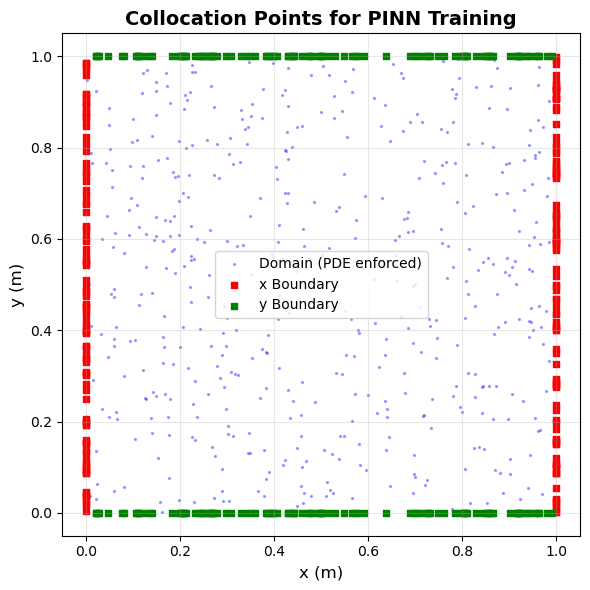

In [3]:
# Creation of training data

def create_training_data(n_domain=500, n_xbound=200, n_ybound=200):
    """
    Create collocation points for training
    
    Returns:
        Dictionary with 'domain', 'boundary' point sets
    """
    # Domain points: random in [0,1] x [0,1]
    x_domain = torch.rand(n_domain, 1)
    y_domain = torch.rand(n_domain, 1)

    # Boundary Left: x=0  for various y
    x_left = torch.zeros(n_xbound // 2, 1)
    # Boundary Right: x=1  for various y
    x_right = torch.ones(n_xbound // 2, 1) * L

    y_xbound = torch.rand(n_xbound, 1)
    x_xbound = torch.cat([x_left, x_right])

    # Boundary Bottom: y=0  for various x
    y_bot = torch.zeros(n_ybound // 2, 1)
    # Boundary Top: y=1  for various x
    y_top = torch.ones(n_ybound // 2, 1) * L

    #y_ybound = torch.cat([y_bot, y_top])
    x_ybound = torch.rand(n_ybound // 2, 1)

    return {
        "domain": (x_domain, y_domain),
        "xbound": (x_xbound, y_xbound), # xy for x bounds; left and right are combined
        "ybound_bot": (x_ybound, y_bot), # xy for y bounds, bottom
        "ybound_top": (x_ybound, y_top) # xy for y bounds, top
    }


# Create data
data = create_training_data()

print(f"Created training data:")
print(f"  Domain points:   {data["domain"][0].shape[0]}")
print(f"  x Boundary points: {data["xbound"][0].shape[0]}")
print(f"  y Boundary points:  {data["ybound_bot"][0].shape[0] + data["ybound_top"][0].shape[0]}")

# Visualize collocation points
plt.figure(figsize=(6, 6))

plt.scatter(data['domain'][0].numpy(), data['domain'][1].numpy(), 
           s=2, alpha=0.3, c='blue', label='Domain (PDE enforced)')
plt.scatter(data['xbound'][0].numpy(), data['xbound'][1].numpy(), 
           s=20, c='red', marker='s', label='x Boundary')
plt.scatter(data['ybound_bot'][0].numpy(), data['ybound_bot'][1].numpy(), 
           s=20, c='green', marker='s', label='y Boundary')
plt.scatter(data['ybound_top'][0].numpy(), data['ybound_top'][1].numpy(), 
           s=20, c='green', marker='s')


# Plot collocation points
plt.xlabel('x (m)', fontsize=12)
plt.ylabel('y (m)', fontsize=12)
plt.title('Collocation Points for PINN Training', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('project1_plots/collocation_points.png')
plt.show()

In [4]:
# Loss function
def calc_loss(data, pinn_model, upper_bound, eq):
    '''
    input: data, pinn model, upper boundary (0 or 100, for poissons or laplace), eq (0 laplace, 1 poissons)
    output: the three major loss types
    '''
    #Compute the pde for the random values in data
    residual = compute_pde_residual(pinn_model, data['domain'][0].detach(), data['domain'][1].detach(), eq) # ideally, should entirely equal 0

    # Calculate the Mean Squared Error of the pde
    loss_pde = torch.mean(residual**2)

    # Boundary Loss for all 4 sides
    loss_bc_x = torch.mean((pinn_model(data['xbound'][0].detach(), data['xbound'][1].detach()))**2) # squared to normalize and adjust 'punishment'
    loss_bc_y_bot = torch.mean((pinn_model(data['ybound_bot'][0].detach(), data['ybound_bot'][1].detach()))**2) # -0 need not be written; efficency!
    loss_bc_y_top = torch.mean((pinn_model(data['ybound_top'][0].detach(), data['ybound_top'][1].detach()) - upper_bound)**2) # -100 for laplace; top
    loss_boundary = (loss_bc_x + loss_bc_y_bot + loss_bc_y_top) 
    loss_total = loss_pde + loss_boundary

    return loss_pde, loss_boundary, loss_total

**Laplace Equation (source is zero):**

An application of a PINN to Laplace's equation. Optimizer attempts to completely minimize the loss function, though it seems to get stuck in a local minimum.

Epoch 0 | Loss: 9941.1396
Epoch 0 | Loss (pde): 0.0110
Epoch 0 | Loss (boundary): 9941.1289
~|--------------------|~
Epoch 500 | Loss: 5465.0186
Epoch 500 | Loss (pde): 44.6607
Epoch 500 | Loss (boundary): 5420.3579
~|--------------------|~
Epoch 1000 | Loss: 3148.2578
Epoch 1000 | Loss (pde): 27.0504
Epoch 1000 | Loss (boundary): 3121.2073
~|--------------------|~
Epoch 1500 | Loss: 2326.4167
Epoch 1500 | Loss (pde): 31.4204
Epoch 1500 | Loss (boundary): 2294.9963
~|--------------------|~
Epoch 2000 | Loss: 1460.9425
Epoch 2000 | Loss (pde): 53.2135
Epoch 2000 | Loss (boundary): 1407.7290
~|--------------------|~
Epoch 2500 | Loss: 1137.3411
Epoch 2500 | Loss (pde): 41.5014
Epoch 2500 | Loss (boundary): 1095.8396
~|--------------------|~
Epoch 3000 | Loss: 905.2923
Epoch 3000 | Loss (pde): 51.4418
Epoch 3000 | Loss (boundary): 853.8505
~|--------------------|~
Epoch 3500 | Loss: 691.0374
Epoch 3500 | Loss (pde): 35.6500
Epoch 3500 | Loss (boundary): 655.3875
~|--------------------|~
E

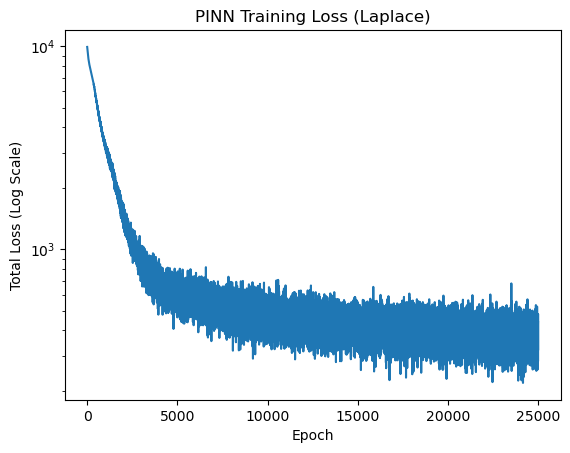

In [15]:
# --- PINN Training, Laplace ---
Lap_pinn_model = PINN()
optimizer = torch.optim.Adam(Lap_pinn_model.parameters(), lr=0.001) # learning rate at least 0.001; seems to fall in a local minimum otherwise
epochs = 25000 # 2d problem; may take a while                     less doesnt seem to do much.
# diminishing returns after ~ 10000

loss_history = []

start = time.time() # timing the training as well
for epoch in range(epochs):
    optimizer.zero_grad() # erase old gradients

    # generate random training data and boundaries (as above)
    data = create_training_data() # note that there are default values in the function

    # static state; no *inital* conditions

    # Optimize
    # find the loss with the function
    loss_pde, loss_boundary, loss_total = calc_loss(data, Lap_pinn_model, 100, 0)
    
    # Backpropagation: compute gradients
    loss_total.backward()
    # Update parameters; uses the above gradient
    optimizer.step()

    loss_history.append(loss_total.item()) # record each loss for plotting

    if epoch % 500 == 0: # every 500 epochs, print the total loss
        print(f"Epoch {epoch} | Loss: {loss_total.item():.4f}")
        print(f"Epoch {epoch} | Loss (pde): {loss_pde.item():.4f}")
        print(f"Epoch {epoch} | Loss (boundary): {loss_boundary.item():.4f}")
        print('~|--------------------|~')
        pass

finish = time.time()
time_el = finish - start
print('~ Training complete! ~')
print(f"Time elapsed: {(time_el // 60):.2f} min {(time_el % 60):.2f} s") # minutes and seconds, since this one is longer.

# Plot the training loss to verify convergence
plt.plot(loss_history)
plt.yscale('log')
plt.title("PINN Training Loss (Laplace)")
plt.xlabel("Epoch")
plt.ylabel("Total Loss (Log Scale)")
plt.savefig('project1_plots/PINN_loss_lap.png')
plt.show()

# possible local minimums identified: ~6000, 1000, 400. This solution currently gets stuck around 400.

# very low learning rate seems to not jump around (naturally), but is much slower (also naturally. good to note, though.)

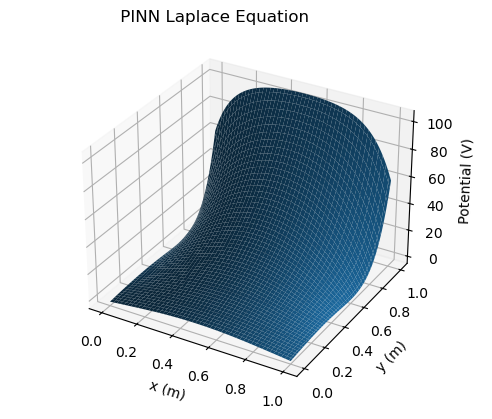

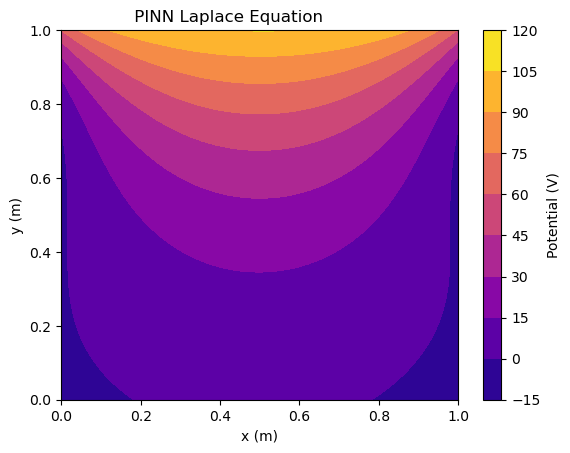

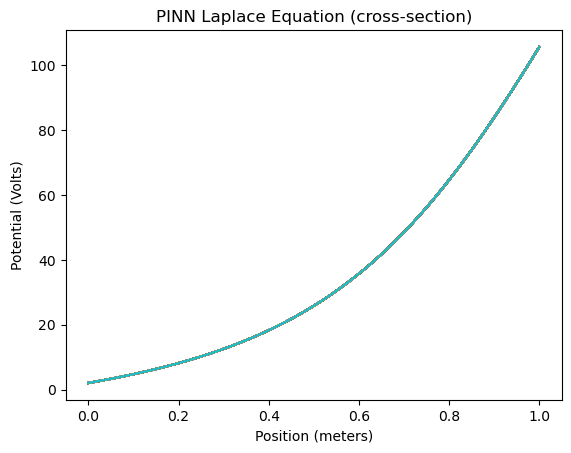

(Center should be approzimately 25 V)
PINN center: 26.286922 V
PINN center error: -5.14769 %


In [19]:
# Solution using trained PINN
def evaluate_pinn(model, nx = 100, ny = 100):
    """
    Evaluate PINN on a regular grid for visualization

    Args:
        model: Trained neural network
        nx: Number of spatial points in x
        ny: Number of spatial points in y

    Returns:
        x_coords, y_coords, V_pred: coords and predicted potentials
    """
    # Create test grid (x is already (nx, 1))
    x = torch.linspace(0, L, nx).reshape(-1, 1)
    y = torch.linspace(0, L, ny).reshape(-1, 1)

    # Create meshgrid
    X, Y = torch.meshgrid(x.squeeze(), y.squeeze(), indexing='ij')
    x_flat = X.reshape(-1, 1)
    y_flat = Y.reshape(-1, 1)

    # Predictions (no gradients needed)
    with torch.no_grad():
        u_pred = model(x_flat, y_flat).reshape(X.shape)


    return X.numpy(), Y.numpy(), u_pred.numpy()

# Evaluate PINN
x_eval_lap, y_eval_lap, u_eval_lap = evaluate_pinn(Lap_pinn_model, nx=100, ny=100)

# plot the PINN solution volumetrically
# 3d volume plot 
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(x_eval_lap, y_eval_lap, u_eval_lap)
ax.set_title('                     PINN Laplace Equation                                 ')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('Potential (V)')
plt.savefig('project1_plots/PINN_Laplace.png')
plt.show()

# contour
ax = plt.axes()
fig = ax.contourf(x_eval_lap, y_eval_lap, u_eval_lap, cmap='plasma')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
plt.colorbar(fig, orientation='vertical', label='Potential (V)')
ax.set_title('                     PINN Laplace Equation                                 ')
plt.savefig('project1_plots/PINN_Laplace_contour.png')
plt.show()


# cross section 
plt.plot(x_eval_lap, u_eval_lap[int(100/2), :]) # tuple slicing is necessary here; [i][:] is indistinguishable [:][i]
plt.title("PINN Laplace Equation (cross-section)")
plt.xlabel("Position (meters)")
plt.ylabel("Potential (Volts)")
plt.savefig('project1_plots/CrossPINN_Laplace.png')
plt.show()

# Error calc; same methodology as in the SOR method. Should be 25 V in the center.
PINN_center = u_eval_lap[int(100/2)][int(100/2)]
print("(Center should be approzimately 25 V)")
print("PINN center:", PINN_center, 'V')
print("PINN center error:", ((25 - PINN_center)/25) * 100, '%')

**Poisson's Equation (using the provided source):**

An application of a PINN to Poisson's equation. Almost exactly the same as for Laplace's, though the boundaries and source are different. This is adjusted through a parameters sent to the calc_loss and compute_pde_residual functions, which adjust the output for either Laplace's or Poisson's equation.

Epoch 0 | Loss: 2.0158
Epoch 0 | Loss (pde): 1.5139
Epoch 0 | Loss (boundary): 0.5019
~|--------------------|~


C:\Users\billy\AppData\Local\Temp\ipykernel_12836\3187761692.py:66: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return u_xx + u_yy + (10 * np.exp(-100*((x.detach() - 0.5)**2 + (y.detach() - 0.5)**2))) # simply return the result - source


Epoch 500 | Loss: 0.2146
Epoch 500 | Loss (pde): 0.2139
Epoch 500 | Loss (boundary): 0.0007
~|--------------------|~
Epoch 1000 | Loss: 0.1508
Epoch 1000 | Loss (pde): 0.1503
Epoch 1000 | Loss (boundary): 0.0006
~|--------------------|~
Epoch 1500 | Loss: 0.0543
Epoch 1500 | Loss (pde): 0.0540
Epoch 1500 | Loss (boundary): 0.0004
~|--------------------|~
Epoch 2000 | Loss: 0.0280
Epoch 2000 | Loss (pde): 0.0278
Epoch 2000 | Loss (boundary): 0.0002
~|--------------------|~
Epoch 2500 | Loss: 0.0210
Epoch 2500 | Loss (pde): 0.0209
Epoch 2500 | Loss (boundary): 0.0001
~|--------------------|~
Epoch 3000 | Loss: 0.0184
Epoch 3000 | Loss (pde): 0.0182
Epoch 3000 | Loss (boundary): 0.0002
~|--------------------|~
Epoch 3500 | Loss: 0.0172
Epoch 3500 | Loss (pde): 0.0170
Epoch 3500 | Loss (boundary): 0.0002
~|--------------------|~
Epoch 4000 | Loss: 0.0147
Epoch 4000 | Loss (pde): 0.0146
Epoch 4000 | Loss (boundary): 0.0002
~|--------------------|~
Epoch 4500 | Loss: 0.0140
Epoch 4500 | Loss

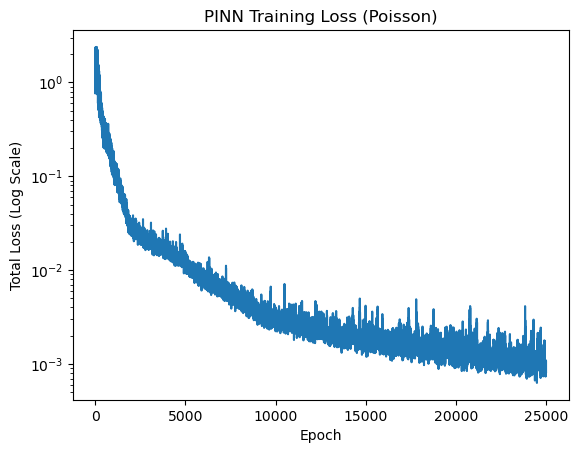

In [17]:
# --- PINN Training, Poisson ---
Pos_pinn_model = PINN()
optimizer = torch.optim.Adam(Pos_pinn_model.parameters(), lr=0.001) # learning rate at least 0.001; seems to fall in a local minimum otherwise
epochs = 25000 # 2d problem; may take a while                     less doesnt seem to do much.


loss_history = []

start = time.time() # timing the training as well
for epoch in range(epochs):
    optimizer.zero_grad() # erase old gradients

    # generate random training data and boundaries (as above)
    data = create_training_data() # note that there are default values in the function

    # static state; no *inital* conditions

    # Optimize
    # find the loss with the function
    loss_pde, loss_boundary, loss_total = calc_loss(data, Pos_pinn_model, 0, 1) # specify boundary and residual for Poisson
    
    # Backpropagation: compute gradients
    loss_total.backward()
    # Update parameters; uses the above gradient
    optimizer.step()

    loss_history.append(loss_total.item()) # record each loss for plotting

    if epoch % 500 == 0: # every 500 epochs, print the total loss
        print(f"Epoch {epoch} | Loss: {loss_total.item():.4f}")
        print(f"Epoch {epoch} | Loss (pde): {loss_pde.item():.4f}")
        print(f"Epoch {epoch} | Loss (boundary): {loss_boundary.item():.4f}")
        print('~|--------------------|~')
        pass

finish = time.time()
time_el = finish - start
print('~ Training complete! ~')
print(f"Time elapsed:  {int(time_el // 60)} min {int(time_el % 60)} s") # minutes and seconds, since this one is longer.

# Plot the training loss to verify convergence
plt.plot(loss_history)
plt.yscale('log')
plt.title("PINN Training Loss (Poisson)")
plt.xlabel("Epoch")
plt.ylabel("Total Loss (Log Scale)")
plt.savefig('project1_plots/PINN_loss_pos.png')
plt.show()

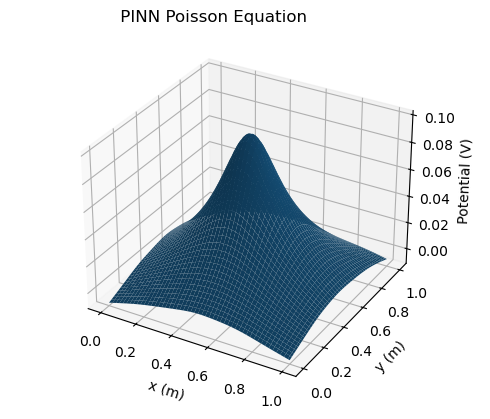

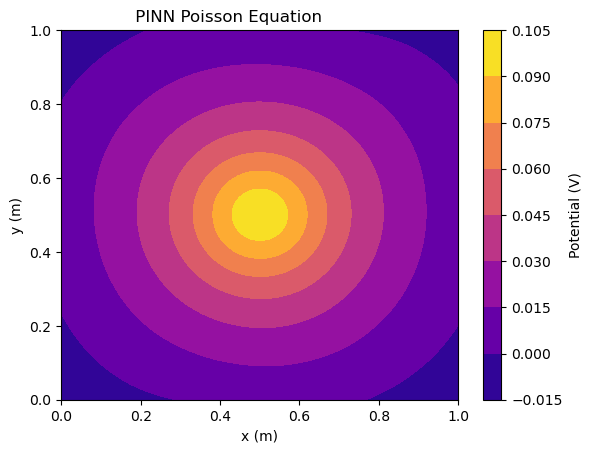

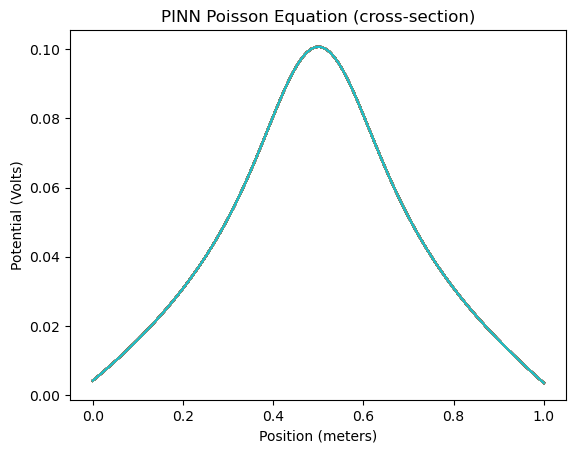

In [20]:
# Solution using trained PINN
def evaluate_pinn(model, nx = 100, ny = 100):
    """
    Evaluate PINN on a regular grid for visualization

    Args:
        model: Trained neural network
        nx: Number of spatial points in x
        ny: Number of spatial points in y

    Returns:
        x_coords, y_coords, V_pred: coords and predicted potentials
    """
    # Create test grid (x is already (nx, 1))
    x = torch.linspace(0, L, nx).reshape(-1, 1)
    y = torch.linspace(0, L, ny).reshape(-1, 1)

    # Create meshgrid
    X, Y = torch.meshgrid(x.squeeze(), y.squeeze(), indexing='ij')
    x_flat = X.reshape(-1, 1)
    y_flat = Y.reshape(-1, 1)

    # Predictions (no gradients needed)
    with torch.no_grad():
        u_pred = model(x_flat, y_flat).reshape(X.shape)


    return X.numpy(), Y.numpy(), u_pred.numpy()

# Evaluate PINN
x_eval_pos, y_eval_pos, u_eval_pos = evaluate_pinn(Pos_pinn_model, nx=100, ny=100)

# plot the PINN solution volumetrically
# 3d volume plot 
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(x_eval_pos, y_eval_pos, u_eval_pos)
ax.set_title('                     PINN Poisson Equation                                 ')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.set_zlabel('Potential (V)')
plt.savefig('project1_plots/PINN_Poisson.png')
plt.show()

# contour
ax = plt.axes()
fig = ax.contourf(x_eval_pos, y_eval_pos, u_eval_pos, cmap='plasma')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
plt.colorbar(fig, orientation='vertical', label='Potential (V)')
ax.set_title('                     PINN Poisson Equation                                 ')
plt.savefig('project1_plots/PINN_Poisson_contour.png')
plt.show()


# cross section 
plt.plot(x_eval_pos, u_eval_pos[int(100/2), :]) # tuple slicing is necessary here; [i][:] is indistinguishable [:][i]
plt.title("PINN Poisson Equation (cross-section)")
plt.xlabel("Position (meters)")
plt.ylabel("Potential (Volts)")
plt.savefig('project1_plots/CrossPINN_Poisson.png')
plt.show()